# Tutorial 10: Detecting Filamentous Fungi

Filamentous fungi like *Neurospora* grow as branching networks of hyphae,
not compact round colonies. Standard threshold detectors struggle with
this morphology because hyphae are thin and have varying intensity.
PhenoTypic includes a specialized pipeline for exactly this scenario.

**What you will learn:**

1. Load a filamentous fungi plate image
2. See why standard detectors miss thin hyphae
3. Use `FilamentousFungiPipeline` for end-to-end processing
4. Visualize fungal detection results

## Load the Fungi Plate

PhenoTypic ships a *Neurospora* filamentous fungi plate image. Let's
take a look at the spreading hyphal morphology.

(<Figure size 640x480 with 1 Axes>, <Axes: >)

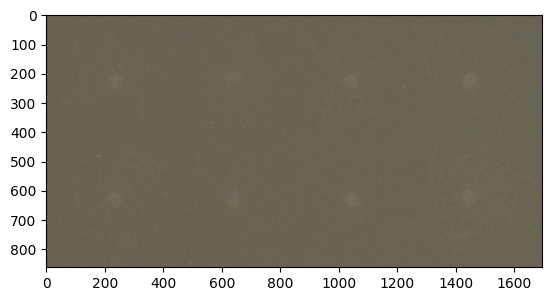

In [1]:
from phenotypic.data import load_fungi_plate

plate = load_fungi_plate()
plate.show()

Notice the spreading mycelium thin, branching filaments radiating from
each inoculation point. This is very different from the compact round
yeast colonies we have worked with so far.

## Protocol Prerequisite: Inoculum Density

The detection algorithm anchors every colony from its inoculation centre
(see [How It Works](../../explanation/filamentous_fungi_algorithm.md)).
For this to succeed, **the spore density of the inoculum must be high
enough to produce a strong, well-defined signal** that the blob detector
and downstream branch calculations can work from. A faint or sparse
deposit will not generate sufficient contrast for reliable detection, and
if the inoculum step fails, all downstream assignment fails with it.

Ideally, the inoculum should be **uniformly bright**. Non-uniform
deposits can sometimes be compensated by preprocessing steps for
example, `HomomorphicFilter` for illumination gradients or the
detector's built-in GMM core extraction for fuzzy edges but severe
patchiness may still cause detection failures or split a single inoculum
into multiple detections.

## Noise impacts branch detection much more than with yeast

In [2]:
from phenotypic.correction import StableDenoise

denoised = StableDenoise().apply(plate)
denoised.detect_mat.dash()

In [3]:
from phenotypic.enhance import ContrastStretching

enh = ContrastStretching().apply(denoised)
enh.detect_mat.dash()

We're looking for very fine structures in the image, 2 to 4 px wide branches. This makes detection very sensitive to noise.

## Why Standard Detectors Struggle

Let's see what happens when we apply `OtsuDetector` to this plate.

In [4]:
from phenotypic.detect import OtsuDetector
from phenotypic.correction import StableDenoise

test = OtsuDetector(ignore_borders=False).apply(plate)
test.gray.dash(show_grid=False)

The Otsu threshold fails to capture a lot of the structure due to the noise. Also

Note: Because this is a center crop of a larger plate, some of the branches touch the border, hence we set `ignore_borders=False`. Usually this is on by default.

## Use FilamentousFungiPipeline

`FilamentousFungiPipeline` is specifically designed for branching fungal
morphology. It chains:

1. **BM3D denoising** removes noise while preserving thin filaments
2. **Homomorphic filtering** corrects uneven illumination
3. **FilamentousFungiDetector** two-stage detection with Dijkstra
   reconnection to capture fragmented hyphal branches

In [5]:
from phenotypic.prefab import FilamentousFungiPipeline
from phenotypic.detect import ManualGridPointDetector, FilamentousFungiDetector

plate = load_fungi_plate()

fungi_pipeline = FilamentousFungiPipeline(
        inoculum_detector=ManualGridPointDetector(coord1=(230, 240),
                                                  coord2=(630, 640),
                                                  shape="disk",
                                                  width=100),
        ignore_borders=False
)
plate = fungi_pipeline.apply(plate)

fig = plate.detect_mat.dash(overlay=True)
fig.show()

Much better! The specialized pipeline captures the full extent of the
mycelium, including thin outer branches that the Otsu detector missed. Most importantly, it reconnects those missed fragments from before

(<Figure size 640x480 with 1 Axes>, <Axes: >)

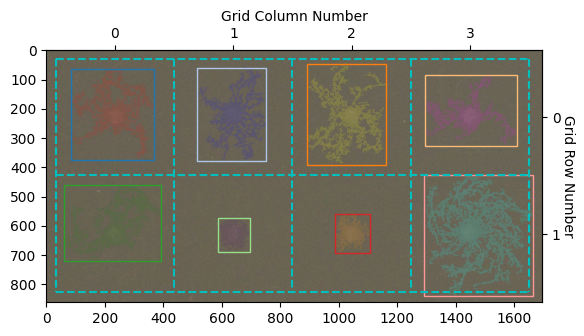

In [6]:
from phenotypic.refine import AsymmetricSpurTrimmer

trimmer = AsymmetricSpurTrimmer()
trimmed_plate = trimmer.apply(plate)
trimmed_plate.show()

## Using radial expansion as a metric of growth

In [7]:
from phenotypic.measure import MeasureSymmetricZones

symmetric_radius = MeasureSymmetricZones()
meas = symmetric_radius.measure(plate)

symmetric_radius.inspect()

## A Note on FrangiVesselness

If you want to build a custom pipeline for filamentous organisms, the
`FrangiVesselness` enhancer is a useful building block. It enhances
tubular structures (hyphae, branches) in `detect_mat` using Hessian-based
vesselness filtering.

```python
from phenotypic.enhance import FrangiVesselness

frangi = FrangiVesselness(sigmas=(0.5, 1.0, 1.5), black_ridges=False)
```

The `FilamentousFungiPipeline` uses a similar approach internally, combined
with phase congruency and minimum-cost path reconnection.

## Summary

You have detected filamentous fungi using PhenoTypic's specialized pipeline:

- **Standard detectors** (like `OtsuDetector`) miss thin hyphae because a single
  threshold cannot capture varying filament intensities.
- **`FilamentousFungiPipeline`** handles this with BM3D denoising, homomorphic
  filtering, and a two-stage detector with Dijkstra reconnection.
- **`FrangiVesselness`** is available for custom pipeline building.

---

**Congratulations you have completed the tutorial series!** You now know
how to:

1. Load and inspect plate images
2. Detect colonies with thresholding and specialized detectors
3. Enhance images before detection
4. Build reusable pipelines
5. Work with grid plates
6. Batch-process many plates from the CLI
7. Measure and export colony features
8. Use prefab pipelines for common scenarios
9. Assess image quality
10. Handle filamentous fungi

For task-specific recipes, head to the [How-To Guides](../../how_to/index.rst).
For deeper understanding, see the [Explanation](../../explanation/index.rst) pages.